In [52]:
import numpy as np
import sympy as sp
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

csv = pd.read_csv('./income.csv')
res = pd.read_csv('./weighted_refactored_income.csv')

incomes = csv['Household Income by Race']

In [3]:
x = sp.Symbol('x')

shortest_path = 691.869904-0.001095*x

n_cameras = shortest_path*0.0017630

ticket_cost = 100

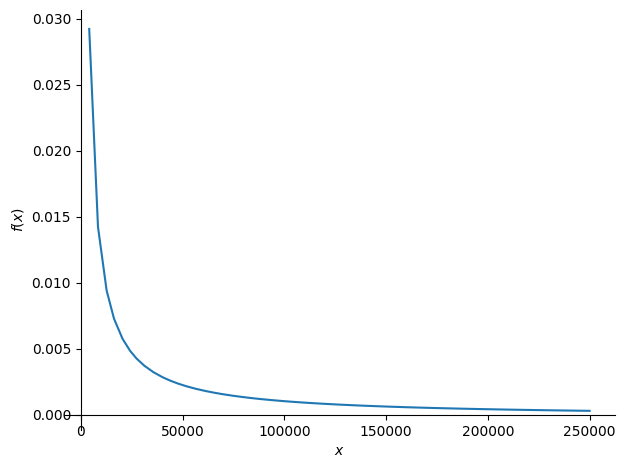

In [4]:
sp.plot(n_cameras/x*ticket_cost, (x, incomes.min(), incomes.max()))

In [ ]:
xs = np.linspace(20000, 200000, int((200000-20000)/100)+1)
y = np.array([float(n_cameras.subs(x, i)/i*ticket_cost) for i in xs])

df = pd.DataFrame(0, columns=['income', 'y'], index=[i for i in range(len(xs))])

ValueError: The first argument to the plotly.graph_objs.Scatter
constructor must be a dict or
an instance of :class:`plotly.graph_objs.Scatter`

In [42]:
df.income = xs
df.y = y

df

,income,y
0,20000.0,0.005906
1,20100.0,0.005875
2,20200.0,0.005845
3,20300.0,0.005816
4,20400.0,0.005786
...,...,...
1796,199600.0,0.000418
1797,199700.0,0.000418
1798,199800.0,0.000417
1799,199900.0,0.000417


In [53]:
red = '#f8766d'
blue = '#619cff'

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=df.income, y=df.y, marker=dict(
                        color=blue,
                        line=dict(color='rgb(248, 248, 249)', width=1)
                    ),)
)

fig.update_layout(
        #xaxis=dict(title="Day of Week",
                   #x=0.5),
        yaxis=dict(title="Cost as proportion of income"),
        xaxis=dict(title="Income"),
        height=500, 
        width=800,
        #legend_title_text='Week type',
        margin=dict(l=75, r=10, t=50, b=80),
        legend=dict(
                yanchor="bottom",
                y=-.2,
                xanchor="left",
                x=0.35,
                orientation="h",
                font=dict(
                    #family="Courier",
                    size=24,
                   # color="black"
                ),
            ),
        font=dict(size=20), plot_bgcolor="#ededed",
    )

fig.write_image('./figure/prop_of_income.png')

fig

In [ ]:
red = '#f8766d'
blue = '#619cff'

xs2 = np.linspace(incomes.min(), incomes.max(), int((incomes.max()-incomes.min())/100)+1)

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=res.income, y=res.shortest_path,  mode='markers', marker=dict(
                        color=blue,
                    ),)
)


fig.add_trace(
    go.Scatter(x=xs2, y=[float(shortest_path.subs(x, i)) for i in xs2], marker=dict(
                        color=red,
                        line=dict(color=red, width=2)
                    ),)
)




fig.update_layout(
        #xaxis=dict(title="Day of Week",
                   #x=0.5),
        yaxis=dict(title="Average commuting time"),
        xaxis=dict(title="Income"),
        height=500, 
        width=800,
        #legend_title_text='Week type',
        margin=dict(l=75, r=10, t=50, b=80),
        showlegend=False,
        legend=dict(
                yanchor="bottom",
                y=-1,
                xanchor="left",
                x=0.35,
                orientation="h",
                font=dict(
                    #family="Courier",
                    size=24,
                   # color="black"
                ),
            ),
        font=dict(size=20), plot_bgcolor="#ededed",
    )


fig